# Projeto de Análise de Sentimento - IMDb PT-BR
**Autores:** Maicon Gomes, Cezar Tosta 
**Objetivo:** Desenvolver um modelo de Machine Learning para classificar avaliações de filmes como positivas ou negativas, utilizando técnicas de NLP.

Shape do dataset: (49459, 4)


,id,text_en,text_pt,sentiment
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg


/tmp/ipykernel_10099/3909206502.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


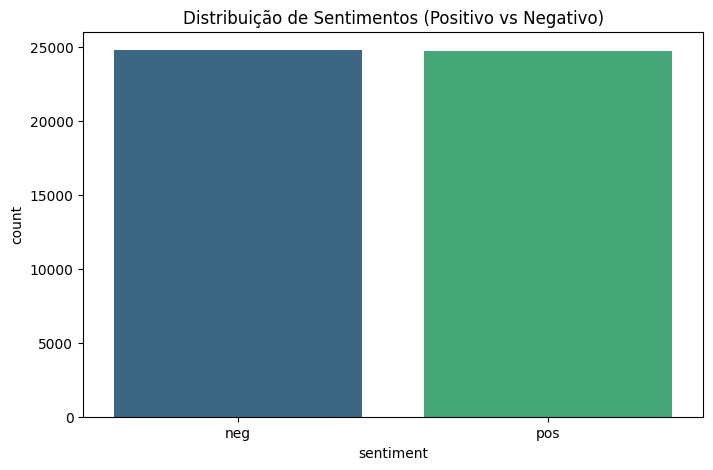


Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      5038
           1       0.87      0.88      0.88      4854

    accuracy                           0.88      9892
   macro avg       0.88      0.88      0.88      9892
weighted avg       0.88      0.88      0.88      9892



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Carregamento dos dados
df = pd.read_csv('../data/imdb-reviews-pt-br.csv')

# Primeira vista dos dados
print(f"Shape do dataset: {df.shape}")
display(df.head())

# Distribuição das classes
plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribuição de Sentimentos (Positivo vs Negativo)')
plt.show()

# Preparação Simples
X = df['text_pt']
y = df['sentiment'].apply(lambda x: 1 if x == 'pos' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vetorização e Modelo
vectorizer = TfidfVectorizer(max_features=3000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

modelo = LogisticRegression()
modelo.fit(X_train_vec, y_train)

# Avaliação
y_pred = modelo.predict(X_test_vec)
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))